# Step 2.2 — Feature Engineering: Word2Vec

**Goal:** Represent each law as a dense vector by training a **Word2Vec** model on the corpus and averaging the embeddings of all tokens in a document.

**Why Word2Vec in addition to TF-IDF?**  
TF-IDF treats each token as an independent dimension — it has no notion that *Schule* and *Bildung* are semantically related. Word2Vec learns a continuous vector space where semantically similar words are geometrically close. For clustering, this means:
- Documents about *education* will be pulled together even if they use different vocabulary.
- The embedding space is dense (typically 100–300 dimensions) rather than sparse (5000+), which benefits distance-based algorithms like K-Means and DBSCAN.

**Approach — document embedding by averaging:**  
We represent each document as the *mean* of all its token vectors. This is simple, fast, and works well when documents are topically coherent (which legal texts generally are). The alternative — Doc2Vec — would require more training data and tuning.

**Training on our own corpus:**  
We train Word2Vec directly on the SGBS corpus rather than using a pre-trained model. This ensures the embedding space reflects legal German as used in Basel-Stadt legislation, not general German text.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import os

CLEAN_DATA_PATH   = "../data/processed/sgbs_clean.csv"
W2V_MODEL_PATH    = "../data/processed/word2vec.model"
W2V_MATRIX_PATH   = "../data/processed/word2vec_matrix.npy"

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../report/figures", exist_ok=True)

df = pd.read_csv(CLEAN_DATA_PATH)
print(f"Records loaded: {len(df)}")

Records loaded: 733


## 2. Prepare Tokenized Corpus

In [2]:
# Word2Vec expects a list of token lists
sentences = [str(text).split() for text in df["text_clean"].fillna("")]

total_tokens = sum(len(s) for s in sentences)
print(f"Documents:    {len(sentences)}")
print(f"Total tokens: {total_tokens:,}")
print(f"Avg tokens per document: {total_tokens / len(sentences):.0f}")
print(f"Sample (first doc, first 10 tokens): {sentences[0][:10]}")

Documents:    733
Total tokens: 292,655
Avg tokens per document: 399
Sample (first doc, first 10 tokens): ['spitäler', 'entfernung', 'spitalliste', 'spitalliste', 'spitalliste', 'leistungsauftrag', 'register', 'spitalliste', 'spitalliste', 'entfernt']


## 3. Train Word2Vec

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `vector_size` | 100 | Standard size for medium corpora; balances expressiveness and overfitting |
| `window` | 5 | Context window of ±5 tokens; captures local co-occurrence in legal sentences |
| `min_count` | 3 | Discard tokens appearing fewer than 3 times — consistent with TF-IDF `min_df` |
| `sg` | 1 | Skip-gram (predict context from word); better for rare words in specialised corpora |
| `epochs` | 10 | Sufficient for a corpus of this size; more epochs show diminishing returns |
| `workers` | 4 | Parallel training threads |

In [3]:
model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=3,
    sg=1,          # skip-gram
    epochs=10,
    workers=4,
    seed=42
)

print(f"Vocabulary size: {len(model.wv)}")
print(f"Vector size:     {model.vector_size}")

Vocabulary size: 15031
Vector size:     100


## 4. Inspect — Nearest Neighbours

In [4]:
# Quick sanity check: semantically related words should be close
probes = ["schule", "arbeit", "umwelt", "sicherheit"]

for word in probes:
    if word in model.wv:
        neighbours = model.wv.most_similar(word, topn=5)
        nb_str = ", ".join(f"{w} ({s:.2f})" for w, s in neighbours)
        print(f"{word:15s} → {nb_str}")
    else:
        print(f"{word:15s} → not in vocabulary")

schule          → schulgesetz (0.74), schulleitung (0.72), volksschulleitung (0.72), brückenangebot (0.71), schülerrat (0.71)
arbeit          → ausführen (0.68), konkurrenzoffert (0.64), abruf (0.63), awa (0.61), personalverleih (0.61)
umwelt          → soziale (0.89), wirtschaft (0.84), sterilisationsgesetz (0.76), gesuche (0.74), energiekommission (0.72)
sicherheit      → innerer (0.77), begegnen (0.76), ruhe (0.76), aufrechterhaltung (0.74), beacht (0.74)


## 5. Build Document Vectors

Each document is represented as the **mean** of its token vectors. Tokens not in the Word2Vec vocabulary (below `min_count`) are skipped. Documents where no tokens are in the vocabulary receive a zero vector and are flagged.

In [5]:
def document_vector(tokens, wv, vector_size):
    """Mean of token vectors. Returns zero vector if no tokens are in vocabulary."""
    vecs = [wv[t] for t in tokens if t in wv]
    if not vecs:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

X_w2v = np.vstack([
    document_vector(tokens, model.wv, model.vector_size)
    for tokens in sentences
])

print(f"Document matrix shape: {X_w2v.shape}  (documents × vector_size)")

# Flag zero vectors
zero_mask = np.all(X_w2v == 0, axis=1)
print(f"Zero vectors (no vocab coverage): {zero_mask.sum()}")
if zero_mask.sum():
    print(df.loc[zero_mask, ["title_de", "systematic_number"]].to_string())

Document matrix shape: (733, 100)  (documents × vector_size)
Zero vectors (no vocab coverage): 0


## 6. Inspect — Token Coverage per Document

Mean token coverage: 89.1%
Min:                 58.8%
Documents <50% coverage: 0


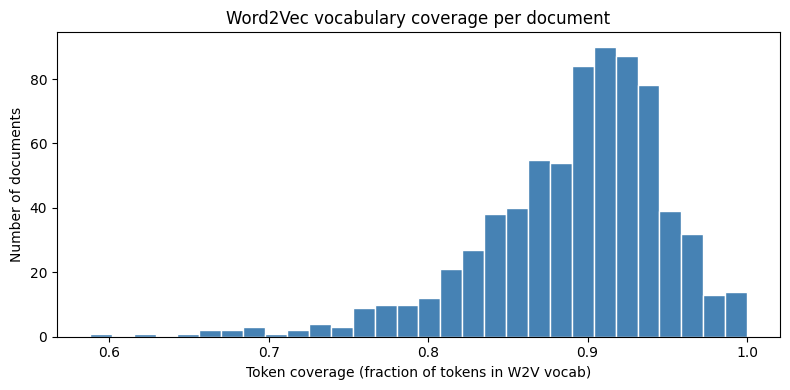

Figure saved.


In [6]:
coverage = [
    sum(1 for t in tokens if t in model.wv) / max(len(tokens), 1)
    for tokens in sentences
]

print(f"Mean token coverage: {np.mean(coverage):.1%}")
print(f"Min:                 {np.min(coverage):.1%}")
print(f"Documents <50% coverage: {sum(c < 0.5 for c in coverage)}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(coverage, bins=30, color="steelblue", edgecolor="white")
ax.set_xlabel("Token coverage (fraction of tokens in W2V vocab)")
ax.set_ylabel("Number of documents")
ax.set_title("Word2Vec vocabulary coverage per document")
plt.tight_layout()
plt.savefig("../report/figures/02_2_w2v_coverage.png", dpi=150)
plt.show()
print("Figure saved.")

## 7. Persist

In [7]:
# Save trained model (allows reloading and querying later)
model.save(W2V_MODEL_PATH)
print(f"Saved Word2Vec model to {W2V_MODEL_PATH}")

# Save document vectors as dense numpy array
np.save(W2V_MATRIX_PATH, X_w2v)
print(f"Saved document matrix ({X_w2v.shape}) to {W2V_MATRIX_PATH}")

Saved Word2Vec model to ../data/processed/word2vec.model
Saved document matrix ((733, 100)) to ../data/processed/word2vec_matrix.npy


## 8. Summary

**What we did:**
- Tokenised 733 cleaned laws and trained a Word2Vec skip-gram model (`vector_size=100`, `window=5`, `min_count=3`, `epochs=10`)
- Verified embedding quality via nearest-neighbour probes on domain keywords
- Represented each document as the mean of its token vectors → matrix shape *(733 × 100)*
- Checked vocabulary coverage and flagged zero-vector documents
- Persisted model as `word2vec.model` and document matrix as `word2vec_matrix.npy`

**Next step:** `03_1_scaling.ipynb` — scale both feature matrices before clustering.